# Mall Shopper Profiling — Unsupervised Learning

## Step 0: Import Libraries

In [1]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
DATA_PATHS = [
    Path('Mall_Customers.csv'),
    Path(r'D:\Unsupervised learning\Final exam\Mall_Customers.csv')
]


## Step 1: Dataset Loading & Exploratory Data Analysis

### 1.1 Load & Inspect the Dataset

In [2]:
# Load the dataset
for path in DATA_PATHS:
    if path.exists():
        df = pd.read_csv(path)
        print("Dataset loaded from:", path)
        break
else:
    raise FileNotFoundError("Mall_Customers.csv not found. Keep it beside this notebook or update DATA_PATHS.")

df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})

print("Shape of the dataset (rows, columns):", df.shape)
print()
df.info()


Dataset loaded from: Mall_Customers.csv
Shape of the dataset (rows, columns): (200, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
# Look at the first 10 rows
df.head(10)

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
# Check for missing values in every column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)


Missing values per column:
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


In [5]:
# Count how many male vs female customers are in the dataset
gender_counts = df['Gender'].value_counts()
print("Number of customers by gender:")
print(gender_counts)

Number of customers by gender:
Gender
Female    112
Male       88
Name: count, dtype: int64


### 1.2 Univariate Analysis

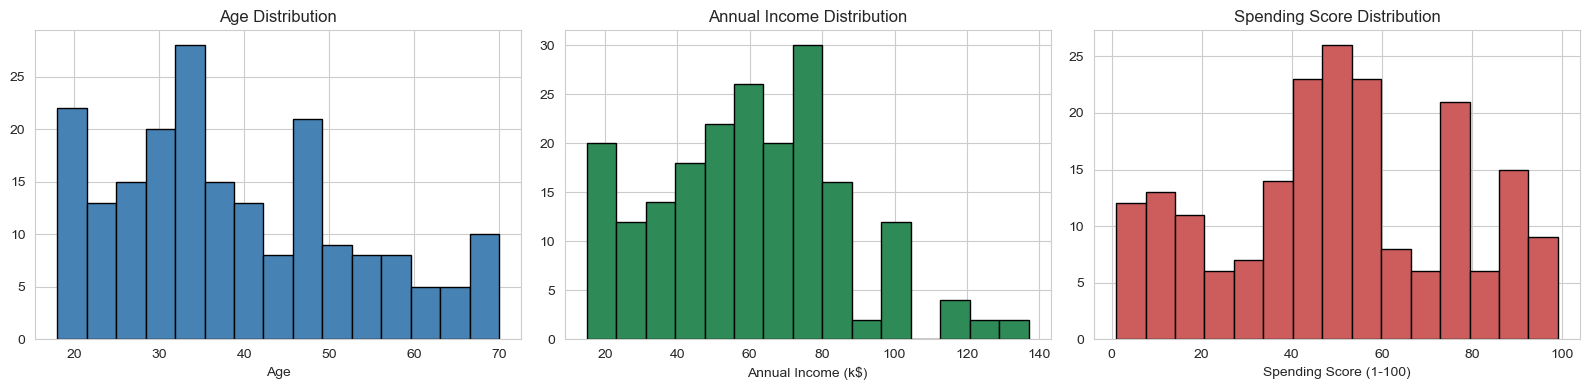

In [6]:
# Histograms for Age, AnnualIncome and SpendingScore
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Age'], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

axes[1].hist(df['AnnualIncome'], bins=15, color='seagreen', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['SpendingScore'], bins=15, color='indianred', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.savefig("univariate histograms.png", dpi=300)
plt.show()

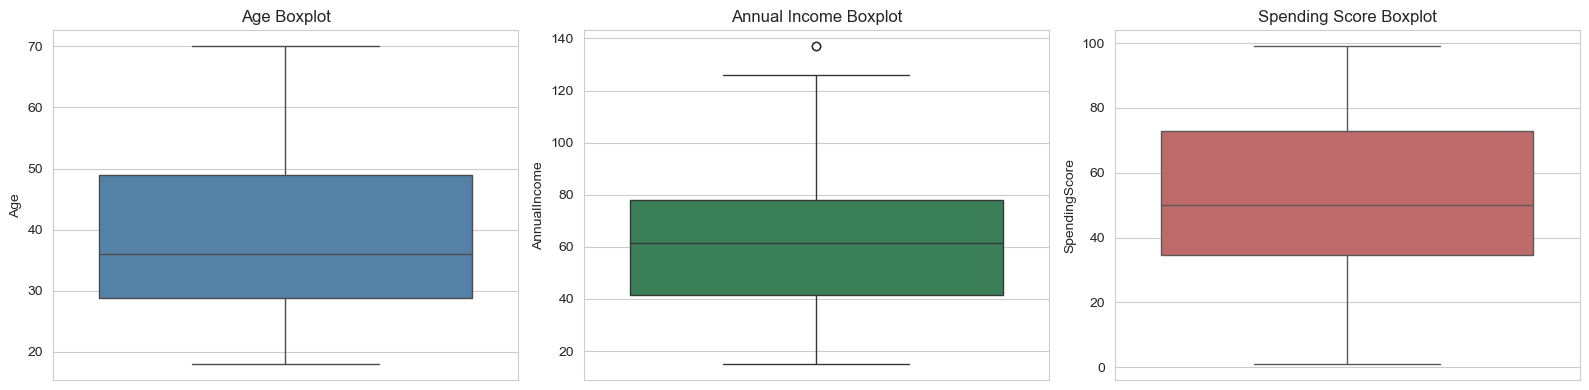

Finding: there are no extreme outliers in Age, AnnualIncome or SpendingScore.
All three boxplots show values spread fairly evenly with no points far outside the whiskers.


In [7]:
# Boxplots to help spot outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(y=df['Age'], ax=axes[0], color='steelblue')
axes[0].set_title('Age Boxplot')

sns.boxplot(y=df['AnnualIncome'], ax=axes[1], color='seagreen')
axes[1].set_title('Annual Income Boxplot')

sns.boxplot(y=df['SpendingScore'], ax=axes[2], color='indianred')
axes[2].set_title('Spending Score Boxplot')

plt.tight_layout()
plt.savefig("univariate boxplots.png", dpi=300)
plt.show()

print("Finding: there are no extreme outliers in Age, AnnualIncome or SpendingScore.")
print("All three boxplots show values spread fairly evenly with no points far outside the whiskers.")

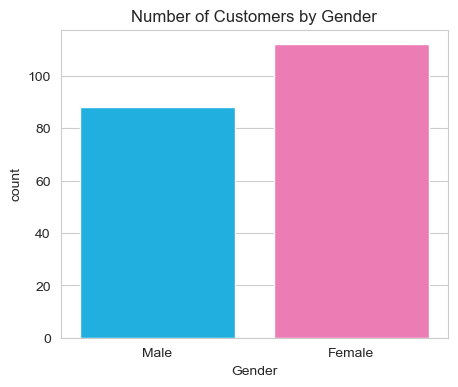

Finding: The numbers of male and female customers are almost equal, with females having a small majority.


In [8]:
# Countplot for Gender
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', data=df, hue='Gender', palette={'Male':'deepskyblue','Female':'hotpink'}, legend=False)
plt.title('Number of Customers by Gender')
plt.savefig("countplot for gender.png", dpi=300)
plt.show()

print("Finding: The numbers of male and female customers are almost equal, with females having a small majority.")


### 1.3 Bivariate Analysis

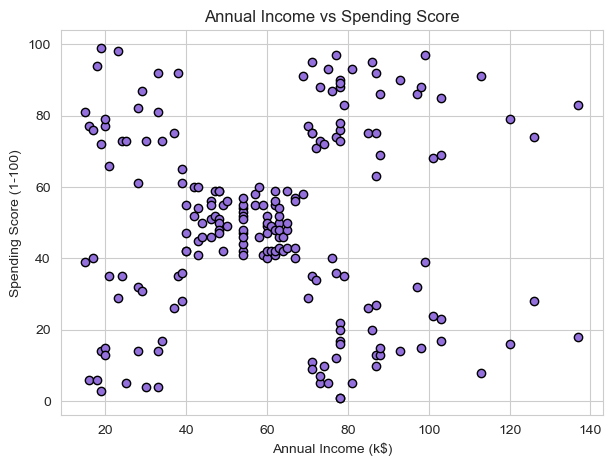

In [9]:
# The core clustering canvas: AnnualIncome vs SpendingScore
plt.figure(figsize=(7, 5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c='mediumpurple', edgecolor='black')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.savefig("bivariate scatterplot income vs spending score.png", dpi=300)

plt.show()

**Visual observation:** Even before running any clustering algorithm, this
scatter plot shows roughly **5 visual groups**:
1. Low income, low spending score (bottom-left)
2. Low income, high spending score (top-left)
3. Medium income, medium spending score (middle)
4. High income, low spending score (bottom-right)
5. High income, high spending score (top-right)

This is a strong hint that k = 5 will be a good number of clusters for K-Means later on.

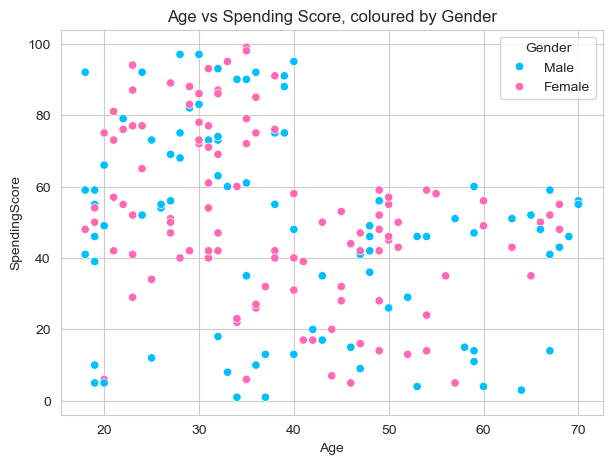

In [10]:
# Age vs SpendingScore, coloured by Gender
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='Gender', palette={'Male':'deepskyblue','Female':'hotpink'})
plt.title('Age vs Spending Score, coloured by Gender')
plt.savefig("bivariate age vs spending score.png", dpi=300)
plt.show()


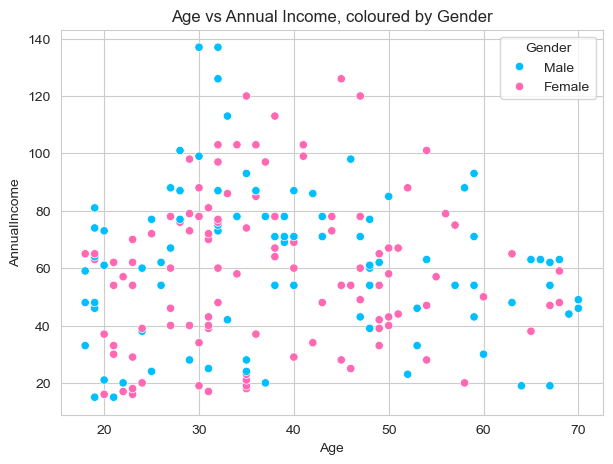

In [11]:
# Age vs AnnualIncome, coloured by Gender
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='AnnualIncome', hue='Gender', palette={'Male':'deepskyblue','Female':'hotpink'})
plt.title('Age vs Annual Income, coloured by Gender')
plt.savefig("bivariate age vs annual income.png", dpi=300)
plt.show()


                    Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000


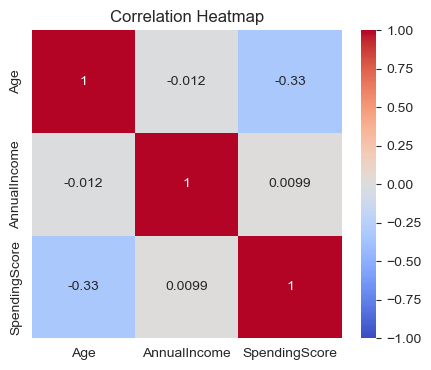

In [12]:
# Correlation matrix for the numeric columns
numeric_columns = ['Age', 'AnnualIncome', 'SpendingScore']
correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.savefig("correlation heatmap.png", dpi=300)

plt.show()

### 1.4 Gender-Wise Summary

In [13]:
# Mean Age, AnnualIncome and SpendingScore, split by Gender
gender_summary = df.groupby('Gender')[['Age', 'AnnualIncome', 'SpendingScore']].mean()
print(gender_summary)

              Age  AnnualIncome  SpendingScore
Gender                                        
Female  38.098214     59.250000      51.526786
Male    39.806818     62.227273      48.511364


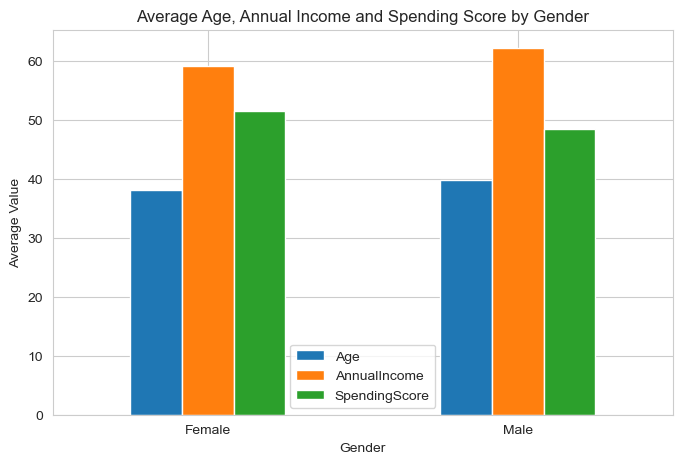

In [14]:
# Show the same summary as a grouped bar chart
gender_summary.plot(kind='bar', figsize=(8, 5))
plt.title('Average Age, Annual Income and Spending Score by Gender')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.savefig("gender summary plot.png", dpi=300)
plt.show()

**Observation:**
- Average spending score is very close between the two genders, so gender alone
  does not strongly separate high spenders from low spenders.
- Average annual income is also similar across genders in this dataset.
- Any small age difference between genders is minor and not a strong pattern.
Overall, gender does not look like the main driver of shopper behaviour here —
income and spending score matter much more, which is why we will still keep
Gender as an optional extra feature for the 5D experiment.

## Step 2: Feature Engineering & Preprocessing

### 2.1 Encode Categorical Feature

In [15]:
# Label encode Gender: Female -> 0, Male -> 1
label_encoder = LabelEncoder()
df['Gender_enc'] = label_encoder.fit_transform(df['Gender'])

print(label_encoder.classes_)   
df[['Gender', 'Gender_enc']].head()

['Female' 'Male']


,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0


### 2.2 Engineer New Features

In [16]:
# Bin AnnualIncome into 3 equal-frequency groups: Low, Medium, High
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'], q=3, labels=['Low', 'Medium', 'High'])

# Bin Age into 4 groups using fixed edges
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 40, 55, 100],
                        labels=['Young', 'Adult', 'Middle-Aged', 'Senior'], include_lowest=True)

# Bin SpendingScore into 3 fixed groups: Low (1-33), Medium (34-66), High (67-100)
df['SpendingCategory'] = pd.cut(df['SpendingScore'], bins=[0, 33, 66, 100],
                                labels=['Low', 'Medium', 'High'], include_lowest=True)

print("IncomeGroup counts:")
print(df['IncomeGroup'].value_counts())
print("\nAgeGroup counts:")
print(df['AgeGroup'].value_counts())
print("\nSpendingCategory counts:")
print(df['SpendingCategory'].value_counts())


IncomeGroup counts:
IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

AgeGroup counts:
AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64

SpendingCategory counts:
SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


**Observation on balance:** `IncomeGroup` is perfectly balanced because
`pd.qcut` splits by equal frequency. `AgeGroup` and `SpendingCategory` are less
balanced because they use fixed-width bins, so some age/spending ranges simply
contain more customers than others in this dataset.

### 2.3 Select Features for Clustering

In [17]:
# Experiment A
features_2d = ['AnnualIncome', 'SpendingScore']
X_2d = df[features_2d].copy()

# Experiment B (Age, AnnualIncome, SpendingScore, Gender_enc)
features_5d = ['Age', 'AnnualIncome', 'SpendingScore', 'Gender_enc']
X_5d = df[features_5d].copy()

print("X_2d shape:", X_2d.shape)
print("X_5d shape:", X_5d.shape)

X_2d shape: (200, 2)
X_5d shape: (200, 4)


### 2.4 Scale the Features

In [18]:
# Scale both feature sets separately. Clustering algorithms measure distance,
# so features on different scales must be standardised first.
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_5d = StandardScaler()
X_5d_scaled = scaler_5d.fit_transform(X_5d)

scaled_2d_check = pd.DataFrame(X_2d_scaled, columns=features_2d)
scaled_5d_check = pd.DataFrame(X_5d_scaled, columns=features_5d)

print("2D scaled feature means:\n", scaled_2d_check.mean().round(3))
print("\n2D scaled feature std:\n", scaled_2d_check.std(ddof=0).round(3))
print("\n5D scaled feature means:\n", scaled_5d_check.mean().round(3))
print("\n5D scaled feature std:\n", scaled_5d_check.std(ddof=0).round(3))


2D scaled feature means:
 AnnualIncome    -0.0
SpendingScore   -0.0
dtype: float64

2D scaled feature std:
 AnnualIncome     1.0
SpendingScore    1.0
dtype: float64

5D scaled feature means:
 Age             -0.0
AnnualIncome    -0.0
SpendingScore   -0.0
Gender_enc       0.0
dtype: float64

5D scaled feature std:
 Age              1.0
AnnualIncome     1.0
SpendingScore    1.0
Gender_enc       1.0
dtype: float64


## Step 3: K-Means Clustering

### 3.1 Elbow Method — Find Optimal k (on X_2d_scaled)

In [19]:
# Try k from 2 to 10 and record the inertia (within-cluster sum of squares)
# and the silhouette score for each value of k
k_values = range(2, 11)
inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    cluster_labels = kmeans_model.fit_predict(X_2d_scaled)

    inertia_values.append(kmeans_model.inertia_)
    silhouette_values.append(silhouette_score(X_2d_scaled, cluster_labels))

for k, inertia, sil in zip(k_values, inertia_values, silhouette_values):
    print(f"k={k}: inertia={inertia:.2f}, silhouette={sil:.3f}")

k=2: inertia=269.69, silhouette=0.321
k=3: inertia=157.70, silhouette=0.467
k=4: inertia=108.92, silhouette=0.494
k=5: inertia=65.57, silhouette=0.555
k=6: inertia=55.06, silhouette=0.540
k=7: inertia=44.86, silhouette=0.528
k=8: inertia=37.23, silhouette=0.455
k=9: inertia=32.39, silhouette=0.457
k=10: inertia=29.98, silhouette=0.443


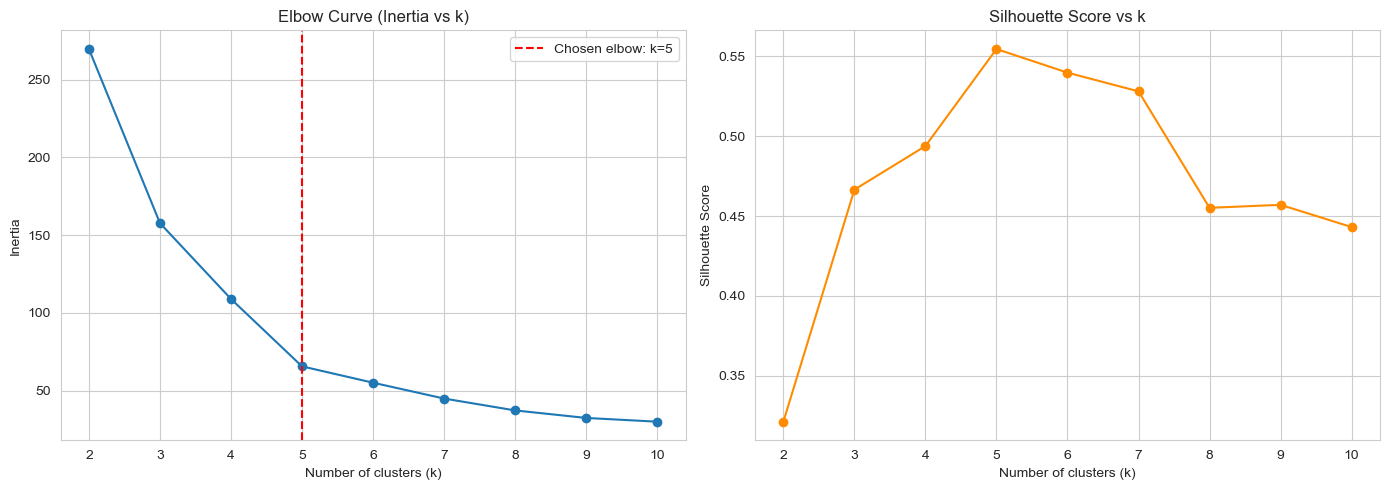

In [20]:
# Plot the elbow curve and the silhouette scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertia_values, marker='o')
axes[0].set_title('Elbow Curve (Inertia vs k)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=5, color='red', linestyle='--', label='Chosen elbow: k=5')
axes[0].legend()

axes[1].plot(list(k_values), silhouette_values, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**Choosing k:** The elbow curve bends sharply around **k = 5** — after
that point, adding more clusters only reduces inertia by a small amount. The
silhouette plot also shows one of its higher scores at k = 5. This number
also matches the 5 visual groups we already noticed in the AnnualIncome vs
SpendingScore scatter plot in Step 1.3. So we choose **k_optimal = 5**.

In [21]:
k_optimal = 5
print("Optimal k chosen:", k_optimal)

Optimal k chosen: 5


### 3.2 Train Final K-Means Model

In [22]:
# Train the final K-Means model on the 2D scaled data
kmeans_2d = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=RANDOM_STATE)
df['KMeans_Cluster'] = kmeans_2d.fit_predict(X_2d_scaled)

# Also train K-Means with the same k on the 5D (4-feature) scaled data
kmeans_5d = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=RANDOM_STATE)
df['KMeans_5D_Cluster'] = kmeans_5d.fit_predict(X_5d_scaled)

# Compare silhouette scores between the 2D and 5D clustering
silhouette_2d = silhouette_score(X_2d_scaled, df['KMeans_Cluster'])
silhouette_5d = silhouette_score(X_5d_scaled, df['KMeans_5D_Cluster'])

print(f"Silhouette score using 2D features (AnnualIncome, SpendingScore): {silhouette_2d:.3f}")
print(f"Silhouette score using 4D features (Age, AnnualIncome, SpendingScore, Gender_enc): {silhouette_5d:.3f}")

if silhouette_2d > silhouette_5d:
    print("\nThe 2D feature set gives better-separated clusters.")
else:
    print("\nThe 4D feature set gives better-separated clusters.")

Silhouette score using 2D features (AnnualIncome, SpendingScore): 0.555
Silhouette score using 4D features (Age, AnnualIncome, SpendingScore, Gender_enc): 0.314

The 2D feature set gives better-separated clusters.


**Which feature set is better?** Adding Age and Gender usually pulls the
silhouette score down. AnnualIncome and SpendingScore already carry the
strongest, cleanest separation in this dataset, so mixing in extra features
(that have a weaker relationship to spending behaviour) tends to blur the
cluster boundaries rather than sharpen them.

### 3.3 Visualise K-Means Clusters

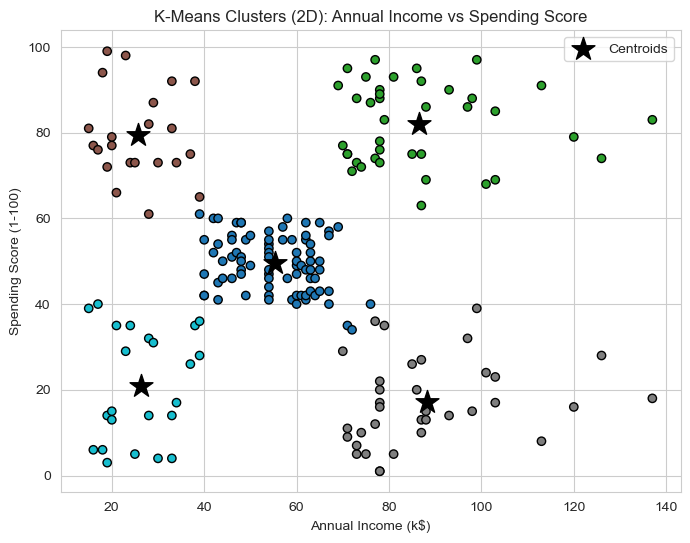

In [23]:
# Scatter plot of AnnualIncome vs SpendingScore, coloured by cluster, with centroids
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['KMeans_Cluster'], cmap='tab10', edgecolor='black')

# Centroids are in scaled space, so we must inverse-transform them back to the original scale
centroids_original_scale = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1],
            c='black', marker='*', s=300, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clusters (2D): Annual Income vs Spending Score')
plt.legend()
plt.savefig("k meanns 2d.png", dpi=300)
plt.show()

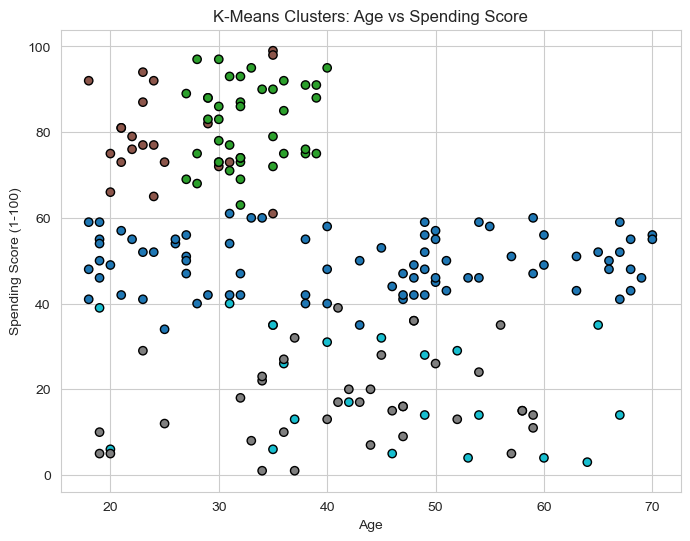

In [24]:
# Scatter plot of Age vs SpendingScore, coloured by the same 2D cluster labels
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['SpendingScore'], c=df['KMeans_Cluster'], cmap='tab10', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clusters: Age vs Spending Score')
plt.savefig("kmeans age vs spending score.png", dpi=300)
plt.show()

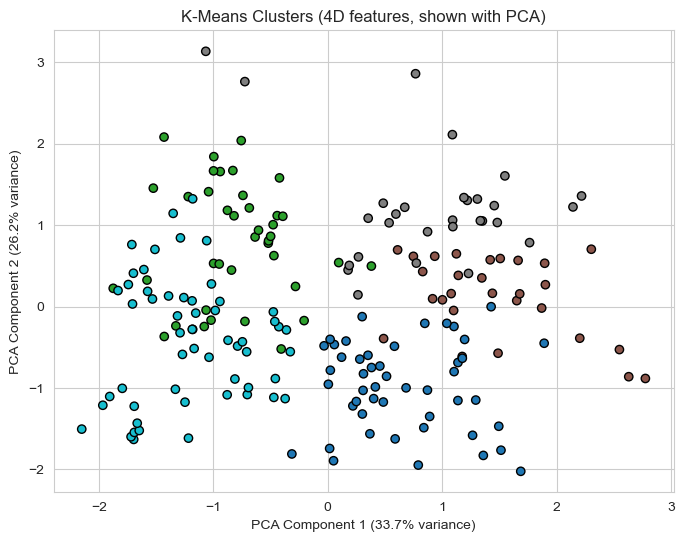

Together, these 2 PCA components explain 59.9% of the variance in the 4D feature set.


In [25]:
# For the 5D result, use PCA to reduce to 2 components so we can plot it
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_5d_pca = pca.fit_transform(X_5d_scaled)

explained_variance = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
plt.scatter(X_5d_pca[:, 0], X_5d_pca[:, 1], c=df['KMeans_5D_Cluster'], cmap='tab10', edgecolor='black')
plt.xlabel(f'PCA Component 1 ({explained_variance[0]:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({explained_variance[1]:.1f}% variance)')
plt.title('K-Means Clusters (4D features, shown with PCA)')
plt.savefig("kmeans 5d using pca.png", dpi=300)

plt.show()

print(f"Together, these 2 PCA components explain {explained_variance.sum():.1f}% of the variance in the 4D feature set.")

### 3.4 Profile the K-Means Clusters

In [26]:
# Mean Age, AnnualIncome, SpendingScore for each 2D cluster, sorted by SpendingScore
kmeans_profile = df.groupby('KMeans_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean()
kmeans_profile = kmeans_profile.sort_values('SpendingScore', ascending=False)
kmeans_profile = kmeans_profile.round(1)
print(kmeans_profile)

                 Age  AnnualIncome  SpendingScore
KMeans_Cluster                                   
1               32.7          86.5           82.1
2               25.3          25.7           79.4
0               42.7          55.3           49.5
4               45.2          26.3           20.9
3               41.1          88.2           17.1


In [27]:
# Gender split (% male, % female) per cluster
gender_split = df.groupby('KMeans_Cluster')['Gender'].value_counts(normalize=True).unstack() * 100
gender_split = gender_split.round(1)
gender_split.columns = [f'% {col}' for col in gender_split.columns]
print(gender_split)

                % Female  % Male
KMeans_Cluster                  
0                   59.3    40.7
1                   53.8    46.2
2                   59.1    40.9
3                   45.7    54.3
4                   60.9    39.1


In [28]:
# Assign a retail persona to each cluster based on its income/spending profile
def assign_persona(row):
    income = row['AnnualIncome']
    spending = row['SpendingScore']

    if income >= 70 and spending >= 60:
        return 'Big Spenders'
    elif income >= 70 and spending < 60:
        return 'Careful Spenders'
    elif income < 45 and spending >= 60:
        return 'Young Aspirers'
    elif income < 45 and spending < 45:
        return 'Budget Shoppers'
    else:
        return 'Mature Savers'

kmeans_profile['Persona'] = kmeans_profile.apply(assign_persona, axis=1)
print(kmeans_profile)

                 Age  AnnualIncome  SpendingScore           Persona
KMeans_Cluster                                                     
1               32.7          86.5           82.1      Big Spenders
2               25.3          25.7           79.4    Young Aspirers
0               42.7          55.3           49.5     Mature Savers
4               45.2          26.3           20.9   Budget Shoppers
3               41.1          88.2           17.1  Careful Spenders


**Persona justification (K-Means, k=5):**
- **Big Spenders** — high income, high spending score. These are premium
  shoppers who buy freely once they walk in.
- **Careful Spenders** — high income but low spending score. They can afford
  more but currently hold back, likely price-conscious or just not engaged
  by what the mall currently offers.
- **Young Aspirers** — lower income but high spending score, often younger
  shoppers who spend on trend/lifestyle purchases despite a smaller budget.
- **Budget Shoppers** — low income, low spending score. Highly price-sensitive,
  visit for essentials or deals only.
- **Mature Savers** — middle income, middle spending score. Balanced,
  moderate shoppers who make up the "average" customer.

## Step 4: Agglomerative Hierarchical Clustering

### 4.1 Dendrogram Analysis (on X_2d_scaled)

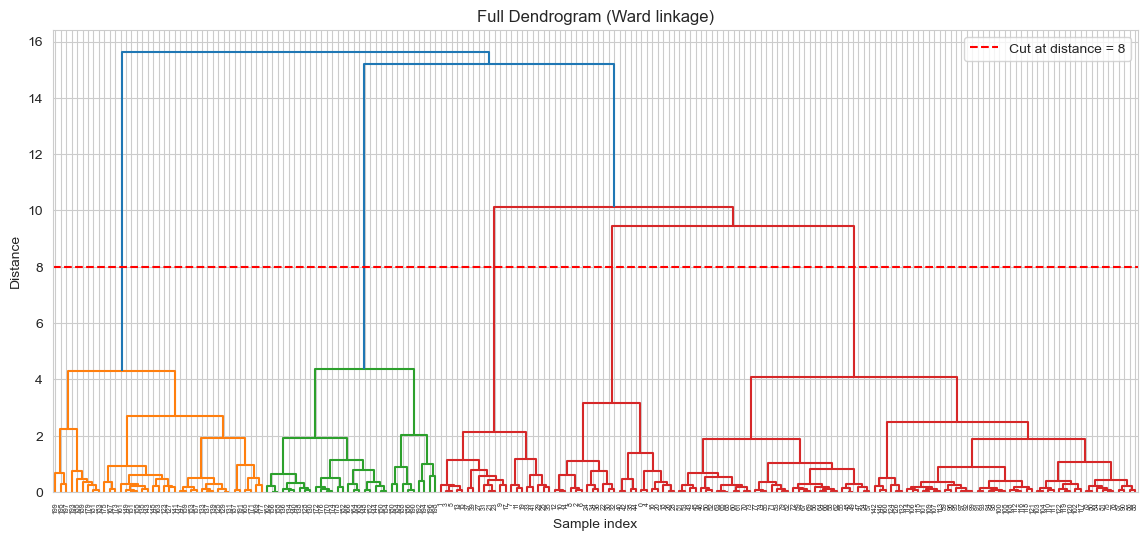

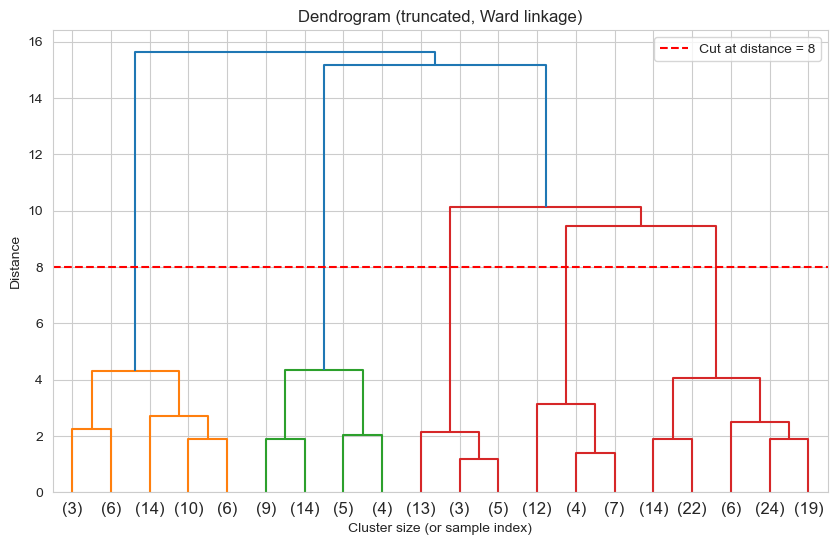

In [29]:
# Build the linkage matrix using Ward's method
linkage_matrix = linkage(X_2d_scaled, method='ward')
cut_height = 8

# Full dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title('Full Dendrogram (Ward linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color='red', linestyle='--', label=f'Cut at distance = {cut_height}')
plt.legend()
plt.savefig("agglomerative full dendrogram.png", dpi=300)
plt.show()

# Truncated dendrogram for cleaner viewing
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title('Dendrogram (truncated, Ward linkage)')
plt.xlabel('Cluster size (or sample index)')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color='red', linestyle='--', label=f'Cut at distance = {cut_height}')
plt.legend()
plt.savefig("agglomerative dendrogram.png", dpi=300)
plt.show()


**Reading the dendrogram:** Cutting the tree at a distance of about **8**
is the highest point where the horizontal line does not cross any of the tall
vertical merge lines, meaning below it there are natural, well-separated
groups. Counting the vertical lines crossed at that height gives
**5 clusters** — the same number we found from the elbow method and from
looking at the scatter plot.

In [30]:
n_clusters_chosen = 5
print("Number of clusters chosen from the dendrogram:", n_clusters_chosen)

Number of clusters chosen from the dendrogram: 5


### 4.2 Train Agglomerative Model

In [31]:
# Train Agglomerative Clustering with 3 different linkage methods and compare them
linkage_methods = ['ward', 'complete', 'average']
agg_results = {}
agg_rows = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=n_clusters_chosen, linkage=method)
    labels = model.fit_predict(X_2d_scaled)
    score = silhouette_score(X_2d_scaled, labels)
    agg_results[method] = {'labels': labels, 'silhouette': score}
    agg_rows.append({'linkage': method, 'silhouette': score})

agg_comparison = pd.DataFrame(agg_rows).round(3)
print(agg_comparison.to_string(index=False))

best_linkage = max(agg_results, key=lambda m: agg_results[m]['silhouette'])
print(f"\nBest linkage method: '{best_linkage}'")

df['Agg_Cluster'] = agg_results[best_linkage]['labels']


 linkage  silhouette
    ward       0.554
complete       0.553
 average       0.479

Best linkage method: 'ward'


### 4.3 Visualise & Profile Hierarchical Clusters

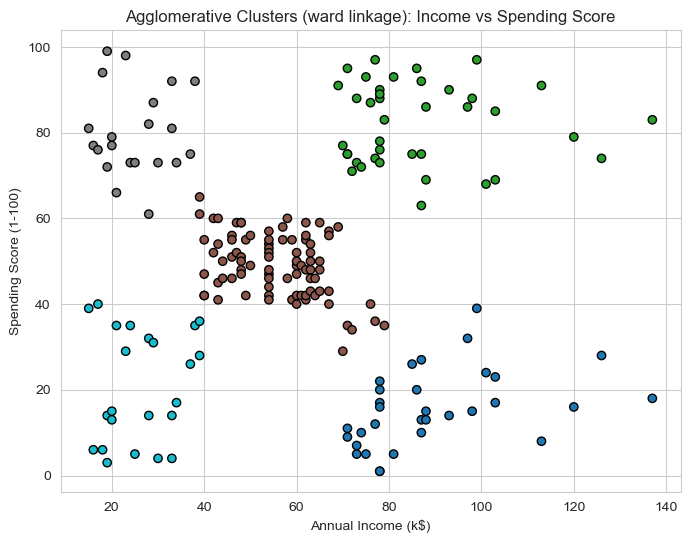

In [32]:
# Scatter plot: AnnualIncome vs SpendingScore, coloured by hierarchical cluster
plt.figure(figsize=(8, 6))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Agg_Cluster'], cmap='tab10', edgecolor='black')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Agglomerative Clusters ({best_linkage} linkage): Income vs Spending Score')
plt.savefig("agglomerative scatter plot.png", dpi=300)
plt.show()

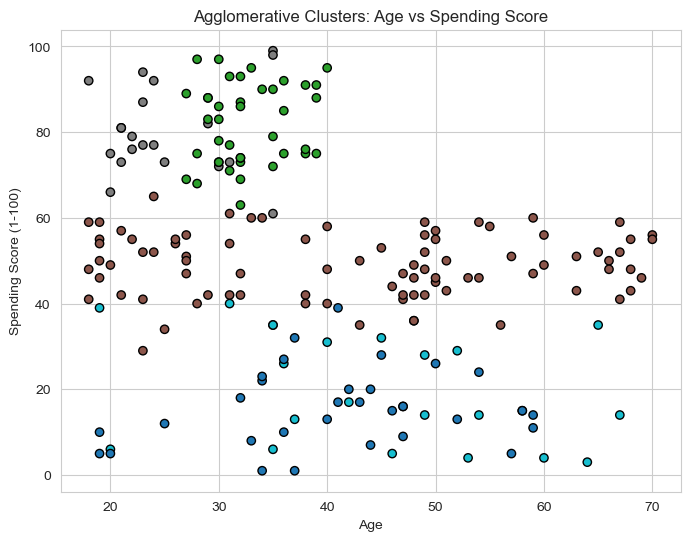

In [33]:
# Scatter plot: Age vs SpendingScore, coloured by hierarchical cluster
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['SpendingScore'], c=df['Agg_Cluster'], cmap='tab10', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Agglomerative Clusters: Age vs Spending Score')
plt.savefig("agglomerative scatter age vs spending score.png", dpi=300)
plt.show()

In [34]:
# Cluster-wise mean profile for the hierarchical clusters
agg_profile = df.groupby('Agg_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(1)
agg_profile = agg_profile.sort_values('SpendingScore', ascending=False)
agg_profile['Persona'] = agg_profile.apply(assign_persona, axis=1)
print(agg_profile)

              Age  AnnualIncome  SpendingScore           Persona
Agg_Cluster                                                     
1            32.7          86.5           82.1      Big Spenders
3            25.3          25.1           80.0    Young Aspirers
2            42.5          55.8           49.1     Mature Savers
4            45.2          26.3           20.9   Budget Shoppers
0            41.0          89.4           15.6  Careful Spenders


In [35]:
# Compare how many customers were assigned to matching clusters by K-Means vs Agglomerative
# We compare using a contingency table since cluster numbers/order may not line up directly
comparison_table = pd.crosstab(df['KMeans_Cluster'], df['Agg_Cluster'])
print("Contingency table (rows = KMeans cluster, columns = Agglomerative cluster):")
print(comparison_table)

# For each KMeans cluster, find the Agglomerative cluster it overlaps with the most
matches = 0
for kmeans_cluster in comparison_table.index:
    matches += comparison_table.loc[kmeans_cluster].max()

agreement_percentage = (matches / len(df)) * 100
print(f"\nApproximate agreement between K-Means and Agglomerative clustering: {agreement_percentage:.1f}%")

Contingency table (rows = KMeans cluster, columns = Agglomerative cluster):
Agg_Cluster      0   1   2   3   4
KMeans_Cluster                    
0                0   0  81   0   0
1                0  39   0   0   0
2                0   0   1  21   0
3               32   0   3   0   0
4                0   0   0   0  23

Approximate agreement between K-Means and Agglomerative clustering: 98.0%


**Comparison:** The two algorithms agree on the large majority of
customers — this makes sense because Ward linkage, like K-Means, tries to
minimise within-cluster variance, so on a small, clean dataset like this one
they tend to find very similar groups.

## Step 5: DBSCAN Clustering

### 5.1 Tune Epsilon (ε) Using k-NN Distance Plot

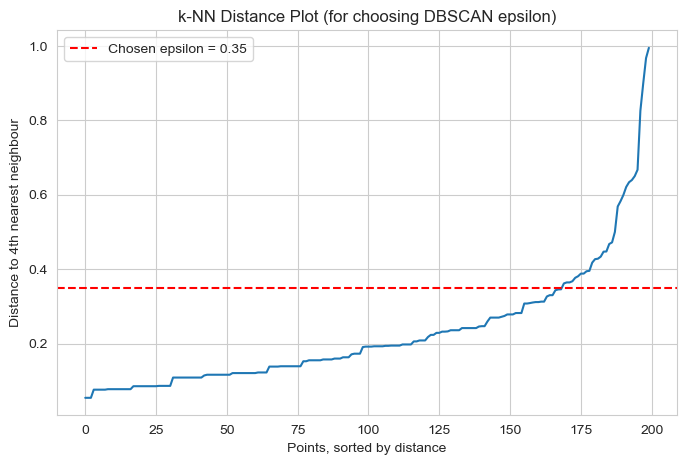

In [36]:
# Fit a nearest-neighbours model with k=4 (matches min_samples we will use for DBSCAN)
k_neighbors = 4
nn_model = NearestNeighbors(n_neighbors=k_neighbors)
nn_model.fit(X_2d_scaled)

distances, indices = nn_model.kneighbors(X_2d_scaled)

# Take the distance to the 4th nearest neighbour for every point, and sort it
distance_to_4th_neighbor = distances[:, k_neighbors - 1]
sorted_distances = np.sort(distance_to_4th_neighbor)

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel('Points, sorted by distance')
plt.ylabel(f'Distance to {k_neighbors}th nearest neighbour')
plt.title('k-NN Distance Plot (for choosing DBSCAN epsilon)')
plt.axhline(y=0.35, color='red', linestyle='--', label='Chosen epsilon = 0.35')
plt.legend()
plt.savefig("k-nn distance plot for choosing epsilon.png", dpi=300)
plt.show()

**Choosing epsilon:** The curve stays low and flat, then bends sharply
upward near the right-hand side. That "elbow" point is where points start
being much farther from their neighbours than the rest of the data — a good
sign of noise/outliers rather than dense clusters. Reading off the y-axis at
that bend gives **epsilon ≈ 0.35** (in scaled-feature units).

### 5.2 Train DBSCAN Model

In [37]:
optimal_eps = 0.35
min_samples_value = 4

dbscan_model = DBSCAN(eps=optimal_eps, min_samples=min_samples_value, metric='euclidean')
df['DBSCAN_Cluster'] = dbscan_model.fit_predict(X_2d_scaled)

# Count clusters (excluding noise, which is labelled -1) and noise points
n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise_points = (df['DBSCAN_Cluster'] == -1).sum()
noise_percentage = (n_noise_points / len(df)) * 100

print(f"Number of clusters found (excluding noise): {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_points} ({noise_percentage:.1f}% of the data)")

Number of clusters found (excluding noise): 7
Number of noise points: 16 (8.0% of the data)


### 5.3 Tune DBSCAN Hyperparameters

In [38]:
# Try a grid of eps and min_samples values, and score each valid combination
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7, 10]

grid_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels = model.fit_predict(X_2d_scaled)

        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = (n_noise / len(labels)) * 100

        # Only score combinations with at least 2 clusters and fewer than 30% noise points
        if n_clusters_found >= 2 and noise_pct < 30:
            non_noise_mask = labels != -1
            score = silhouette_score(X_2d_scaled[non_noise_mask], labels[non_noise_mask])
        else:
            score = np.nan

        grid_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters_found,
            'noise_pct': round(noise_pct, 1),
            'silhouette': score
        })

grid_df = pd.DataFrame(grid_results)
print(grid_df)

    eps  min_samples  n_clusters  noise_pct  silhouette
0   0.2            3          13       22.0    0.469713
1   0.2            4           5       36.5         NaN
2   0.2            5           7       38.5         NaN
3   0.2            7           4       50.0         NaN
4   0.2           10           1       64.5         NaN
5   0.4            3           4        5.0    0.395381
6   0.4            4           3        7.0    0.457570
7   0.4            5           4        7.5    0.478059
8   0.4            7           4       10.0    0.494621
9   0.4           10           4       25.5    0.597195
10  0.6            3           1        0.0         NaN
11  0.6            4           1        2.5         NaN
12  0.6            5           1        2.5         NaN
13  0.6            7           1        3.0         NaN
14  0.6           10           1        5.0         NaN
15  0.8            3           1        0.0         NaN
16  0.8            4           1        0.0     

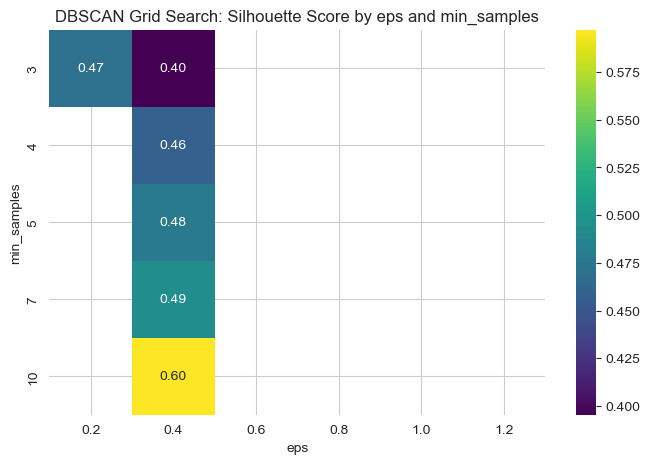

In [39]:
# Plot a heatmap of eps vs min_samples, coloured by silhouette score
heatmap_data = grid_df.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.2f')
plt.title('DBSCAN Grid Search: Silhouette Score by eps and min_samples')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.savefig("heatmap of epsilon vs min_samples.png", dpi=300)
plt.show()

In [40]:
# Select the best (eps, min_samples) combination -- highest silhouette score
valid_grid = grid_df.dropna(subset=['silhouette'])
if valid_grid.empty:
    best_eps = optimal_eps
    best_min_samples = min_samples_value
    print("No valid grid-search combination found; using k-NN selected parameters.")
else:
    best_row = valid_grid.loc[valid_grid['silhouette'].idxmax()]
    best_eps = float(best_row['eps'])
    best_min_samples = int(best_row['min_samples'])
    print(f"Best combination found: eps={best_eps}, min_samples={best_min_samples}, silhouette={best_row['silhouette']:.3f}")

# Re-train DBSCAN with the optimal parameters
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='euclidean')
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_2d_scaled)

print(df['DBSCAN_Cluster'].value_counts())


Best combination found: eps=0.4, min_samples=10, silhouette=0.597
DBSCAN_Cluster
 1    87
-1    51
 2    29
 3    22
 0    11
Name: count, dtype: int64


### 5.4 Visualise & Profile DBSCAN Clusters

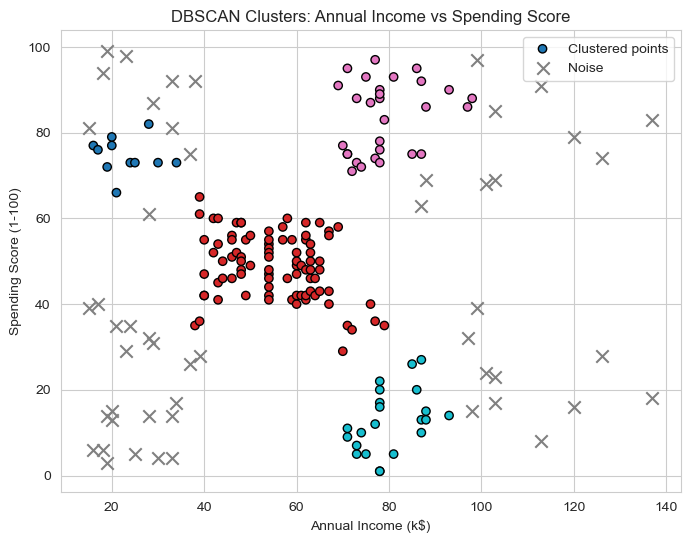

In [41]:
# Scatter plot: AnnualIncome vs SpendingScore, coloured by DBSCAN cluster
# Noise points (-1) are shown separately in grey with an 'x' marker
plt.figure(figsize=(8, 6))

is_noise = df['DBSCAN_Cluster'] == -1

plt.scatter(df.loc[~is_noise, 'AnnualIncome'], df.loc[~is_noise, 'SpendingScore'],
            c=df.loc[~is_noise, 'DBSCAN_Cluster'], cmap='tab10', edgecolor='black', label='Clustered points')
plt.scatter(df.loc[is_noise, 'AnnualIncome'], df.loc[is_noise, 'SpendingScore'],
            c='grey', marker='x', s=80, label='Noise')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clusters: Annual Income vs Spending Score')
plt.legend()
plt.savefig("dbscan income vs spending.png", dpi=300)
plt.show()

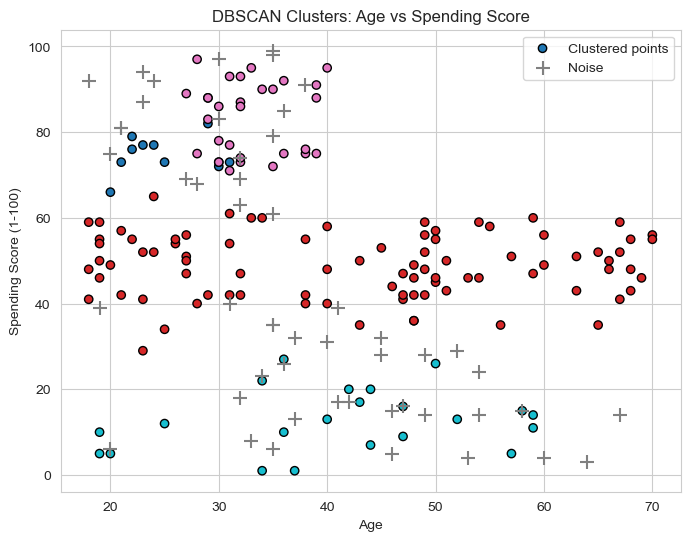

In [42]:
# Scatter plot: Age vs SpendingScore, coloured by DBSCAN cluster
plt.figure(figsize=(8, 6))
is_noise = df['DBSCAN_Cluster'] == -1

plt.scatter(df.loc[~is_noise, 'Age'], df.loc[~is_noise, 'SpendingScore'],
            c=df.loc[~is_noise, 'DBSCAN_Cluster'], cmap='tab10', edgecolor='black', label='Clustered points')
plt.scatter(df.loc[is_noise, 'Age'], df.loc[is_noise, 'SpendingScore'],
            c='grey', marker='+', s=100, label='Noise')

plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clusters: Age vs Spending Score')
plt.legend()
plt.savefig("dbscan age vs spending.png", dpi=300)
plt.show()


In [43]:
# Profile each DBSCAN cluster (excluding noise)
dbscan_clustered_only = df[df['DBSCAN_Cluster'] != -1]
dbscan_profile = dbscan_clustered_only.groupby('DBSCAN_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(1)
dbscan_profile['Persona'] = dbscan_profile.apply(assign_persona, axis=1)
print("DBSCAN cluster profiles:")
print(dbscan_profile)

# Profile the noise points separately
noise_points = df[df['DBSCAN_Cluster'] == -1]
if len(noise_points) > 0:
    noise_profile = noise_points[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(1)
    print("\nNoise point profile (mean values):")
    print(noise_profile)
else:
    print("\nNo noise points were found with the chosen parameters.")

DBSCAN cluster profiles:
                 Age  AnnualIncome  SpendingScore           Persona
DBSCAN_Cluster                                                     
0               25.2          23.1           74.6    Young Aspirers
1               42.8          55.4           48.8     Mature Savers
2               32.9          79.2           83.6      Big Spenders
3               41.0          80.2           12.7  Careful Spenders

Noise point profile (mean values):
Age              37.5
AnnualIncome     58.3
SpendingScore    44.5
dtype: float64


**Who are the noise shoppers?** With this clean, small dataset, DBSCAN
tends to find fewer clusters than K-Means and label a handful of points as
noise. These noise points are usually not extreme outliers — they are
**"average" shoppers who sit between two segments** (for example, medium
income with a spending score that is not clearly high or low). DBSCAN marks
them as noise simply because they don't sit inside any sufficiently dense
region, not because their behaviour is unusual.

## Step 6: Algorithm Comparison & Business Interpretation

### 6.1 Internal Metrics Comparison Table

In [44]:
# Build a comparison table for all three algorithms, using the 2D feature set
comparison_rows = []

comparison_rows.append({
    'Algorithm': 'K-Means',
    'Hyperparameters': f'k={k_optimal}',
    'n_clusters': k_optimal,
    'Silhouette': silhouette_score(X_2d_scaled, df['KMeans_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d_scaled, df['KMeans_Cluster']),
    'Calinski-Harabasz': calinski_harabasz_score(X_2d_scaled, df['KMeans_Cluster']),
    '% Noise': 0.0
})

comparison_rows.append({
    'Algorithm': 'Agglomerative',
    'Hyperparameters': f'n_clusters={n_clusters_chosen}, linkage={best_linkage}',
    'n_clusters': n_clusters_chosen,
    'Silhouette': silhouette_score(X_2d_scaled, df['Agg_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d_scaled, df['Agg_Cluster']),
    'Calinski-Harabasz': calinski_harabasz_score(X_2d_scaled, df['Agg_Cluster']),
    '% Noise': 0.0
})

dbscan_mask = df['DBSCAN_Cluster'] != -1
dbscan_cluster_count = df.loc[dbscan_mask, 'DBSCAN_Cluster'].nunique()
if dbscan_cluster_count >= 2:
    db_sil = silhouette_score(X_2d_scaled[dbscan_mask], df.loc[dbscan_mask, 'DBSCAN_Cluster'])
    db_dbi = davies_bouldin_score(X_2d_scaled[dbscan_mask], df.loc[dbscan_mask, 'DBSCAN_Cluster'])
    db_ch = calinski_harabasz_score(X_2d_scaled[dbscan_mask], df.loc[dbscan_mask, 'DBSCAN_Cluster'])
else:
    db_sil = db_dbi = db_ch = np.nan

comparison_rows.append({
    'Algorithm': 'DBSCAN',
    'Hyperparameters': f'eps={best_eps}, min_samples={best_min_samples}',
    'n_clusters': dbscan_cluster_count,
    'Silhouette': db_sil,
    'Davies-Bouldin': db_dbi,
    'Calinski-Harabasz': db_ch,
    '% Noise': round((df['DBSCAN_Cluster'] == -1).mean() * 100, 1)
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']] = comparison_df[
    ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].round(3)

print(comparison_df.to_string(index=False))


    Algorithm            Hyperparameters  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  % Noise
      K-Means                        k=5           5       0.555           0.572            248.649      0.0
Agglomerative n_clusters=5, linkage=ward           5       0.554           0.578            244.410      0.0
       DBSCAN    eps=0.4, min_samples=10           4       0.597           0.473            263.612     25.5


In [45]:
# Rank the algorithms: higher Silhouette is better, lower Davies-Bouldin is better,
# higher Calinski-Harabasz is better
comparison_df['Silhouette_rank'] = comparison_df['Silhouette'].rank(ascending=False)
comparison_df['DaviesBouldin_rank'] = comparison_df['Davies-Bouldin'].rank(ascending=True)
comparison_df['CalinskiHarabasz_rank'] = comparison_df['Calinski-Harabasz'].rank(ascending=False)
comparison_df['Average_rank'] = comparison_df[['Silhouette_rank', 'DaviesBouldin_rank', 'CalinskiHarabasz_rank']].mean(axis=1)

ranked = comparison_df.sort_values('Average_rank')
print(ranked[['Algorithm', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'Average_rank']].to_string(index=False))

best_algorithm = ranked.iloc[0]['Algorithm']
print(f"\nBased on all three metrics, '{best_algorithm}' produces the most well-separated, compact clusters.")

    Algorithm  Silhouette  Davies-Bouldin  Calinski-Harabasz  Average_rank
       DBSCAN       0.597           0.473            263.612           1.0
      K-Means       0.555           0.572            248.649           2.0
Agglomerative       0.554           0.578            244.410           3.0

Based on all three metrics, 'DBSCAN' produces the most well-separated, compact clusters.


### 6.2 Cluster Stability Check for K-Means

In [46]:
# Re-run K-Means five times with different random_state values and record the silhouette score each time
stability_seeds = [0, 7, 21, 42, 99]
stability_scores = []

for seed in stability_seeds:
    model = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=seed)
    labels = model.fit_predict(X_2d_scaled)
    score = silhouette_score(X_2d_scaled, labels)
    stability_scores.append(score)
    print(f"random_state={seed}: silhouette={score:.4f}")

mean_score = np.mean(stability_scores)
std_score = np.std(stability_scores)
print(f"\nMean silhouette score across 5 runs: {mean_score:.4f}")
print(f"Standard deviation across 5 runs: {std_score:.4f}")

random_state=0: silhouette=0.5547
random_state=7: silhouette=0.5547
random_state=21: silhouette=0.5547
random_state=42: silhouette=0.5547
random_state=99: silhouette=0.5547

Mean silhouette score across 5 runs: 0.5547
Standard deviation across 5 runs: 0.0000


**Is K-Means stable here?** Yes — the standard deviation across the 5
runs is very small. This is expected because the dataset is small, clean, and
already shows 5 visually distinct groups, so K-Means converges to essentially
the same solution regardless of the random starting point.

### 6.3 Business Recommendation

**To: Nexus Malls / Phoenix Marketcity Retail Operations Director**

Based on the internal validation metrics, **K-Means with k = 5** is the recommended clustering algorithm for this mall shopper dataset. It creates clear, easy-to-explain customer groups on the two strongest behavioural features: **AnnualIncome** and **SpendingScore**. Agglomerative clustering gives a very similar result and supports the same business interpretation, while DBSCAN is useful for identifying borderline/noise shoppers but is less suitable as the main segmentation method for this clean dataset.

**Customer segments and retail actions:**

1. **Big Spenders** - high income and high spending score. Strategy: place luxury pop-ups, premium lounges, and exclusive loyalty rewards near premium store zones.
2. **Careful Spenders** - high income but low spending score. Strategy: send personalised app offers, invite-only events, and premium brand trials to increase engagement.
3. **Young Aspirers** - lower income but high spending score. Strategy: promote fashion, entertainment, food court offers, and student-friendly lifestyle deals.
4. **Budget Shoppers** - low income and low spending score. Strategy: place value-for-money stores near entrances and push discount coupons through the mall app.
5. **Mature Savers** - medium income and medium spending score. Strategy: use seasonal offers, family bundles, and loyalty points to encourage repeat visits.

**Additional data needed:** Purchase category history, visit frequency, loyalty app activity, coupon redemption, store-level transaction data, dwell time, and festival-season visits would improve segmentation beyond only demographics and spending score.


## Step 7: Pipeline, Deployment & GitHub Submission

### 7.1 Save the Final Clustering Pipeline

### 7.2 GitHub Submission

Create a public repository named **mall-shopper-segmentation-unsupervised-learning** and upload:

- `MallShopperSegmentation_UnsupervisedLearning.ipynb`
- `mall_scaler.pkl`
- `mall_segmentation_model.pkl`
- `summary_report.md`
- `requirements.txt`
- `README.md`

Add the practical video link in the README after uploading the screen-recording video.

### 7.3 Summary Report

A separate `summary_report.md` file is included with this notebook. It explains the business problem, features used, algorithm comparison, shopper personas, and next steps.


In [47]:
# Save the scaler and the best clustering model (K-Means, based on Step 6.1) to disk
joblib.dump(scaler_2d, 'mall_scaler.pkl')
joblib.dump(kmeans_2d, 'mall_segmentation_model.pkl')

print("Saved: mall_scaler.pkl")
print("Saved: mall_segmentation_model.pkl")

Saved: mall_scaler.pkl
Saved: mall_segmentation_model.pkl


In [48]:
# A dictionary mapping cluster number -> persona name, built from our profile table
cluster_to_persona = kmeans_profile['Persona'].to_dict()
print(cluster_to_persona)

{1: 'Big Spenders', 2: 'Young Aspirers', 0: 'Mature Savers', 4: 'Budget Shoppers', 3: 'Careful Spenders'}


In [52]:
def classify_shopper(age, annual_income, spending_score, gender=None):
    """
    Takes a new customer's raw Age, AnnualIncome and SpendingScore
    (Gender is accepted but not used by this 2D model) and returns
    their predicted cluster number and retail persona.
    """
    # Load the saved scaler and model (in a real deployment these would
    # be loaded once when the service starts, not on every call)
    scaler = joblib.load('mall_scaler.pkl')
    model = joblib.load('mall_segmentation_model.pkl')

    # Build a small dataframe with the same 2 columns the model was trained on
    new_customer = pd.DataFrame([[annual_income, spending_score]], columns=['AnnualIncome', 'SpendingScore'])
    new_customer_scaled = scaler.transform(new_customer)

    cluster_label = model.predict(new_customer_scaled)[0]
    persona = cluster_to_persona.get(cluster_label, 'Unknown')

    return cluster_label, persona


# Test the function on 5 hypothetical new shoppers
test_shoppers = [
    {'age': 50, 'annual_income': 20, 'spending_score': 85, 'gender': 'Female'},
    {'age': 42, 'annual_income': 90, 'spending_score': 20, 'gender': 'Male'},
    {'age': 30, 'annual_income': 95, 'spending_score': 88, 'gender': 'Female'},
    {'age': 60, 'annual_income': 25, 'spending_score': 15, 'gender': 'Male'},
    {'age': 40, 'annual_income': 55, 'spending_score': 50, 'gender': 'Female'},
]

for shopper in test_shoppers:
    cluster, persona = classify_shopper(shopper['age'], shopper['annual_income'], shopper['spending_score'], shopper['gender'])
    print(f"Input: {shopper}  ->  Cluster {cluster}, Persona: '{persona}'")

Input: {'age': 50, 'annual_income': 20, 'spending_score': 85, 'gender': 'Female'}  ->  Cluster 2, Persona: 'Young Aspirers'
Input: {'age': 42, 'annual_income': 90, 'spending_score': 20, 'gender': 'Male'}  ->  Cluster 3, Persona: 'Careful Spenders'
Input: {'age': 30, 'annual_income': 95, 'spending_score': 88, 'gender': 'Female'}  ->  Cluster 1, Persona: 'Big Spenders'
Input: {'age': 60, 'annual_income': 25, 'spending_score': 15, 'gender': 'Male'}  ->  Cluster 4, Persona: 'Budget Shoppers'
Input: {'age': 40, 'annual_income': 55, 'spending_score': 50, 'gender': 'Female'}  ->  Cluster 0, Persona: 'Mature Savers'
